# import Libraries

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline

In [33]:
new_df= pd.read_csv("merged_data.csv")

### 2.a Methods for the question: Temporal Patterns and Seasonality: Demonstrate how the number of charging events varies during the day, the week, and between seasons. What patterns can you observe, and how do you explain them? 

In [34]:
new_df['connectionTime'] = pd.to_datetime(new_df['connectionTime'])
new_df['disconnectTime'] = pd.to_datetime(new_df['disconnectTime'])

C:\Users\86157\AppData\Local\Temp\ipykernel_27332\1511561215.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(start=start, end=end, freq='H')


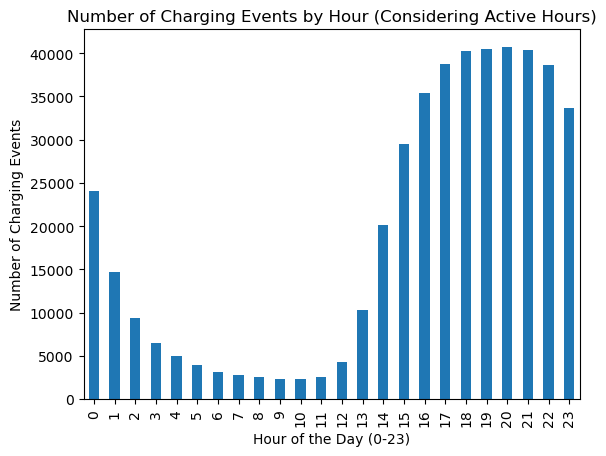

In [35]:
def get_active_hours(row):
    start = row['connectionTime']
    end = row['disconnectTime']
    time_range = pd.date_range(start=start, end=end, freq='H')
    return [time.hour for time in time_range]
new_df['active_hours'] = new_df.apply(get_active_hours, axis=1)
all_hours = [hour for hours in new_df['active_hours'] for hour in hours]
hourly_counts = pd.Series(all_hours).value_counts().sort_index()
hourly_counts.plot(kind='bar')
plt.title('Number of Charging Events by Hour (Considering Active Hours)')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Charging Events')
plt.xticks(range(24))
plt.show()

The number of charging sessions is relatively low between 1 am and 1 pm, while the peak charging period occurs between 5 pm and 10 pm, reflecting people's preference for nighttime charging.

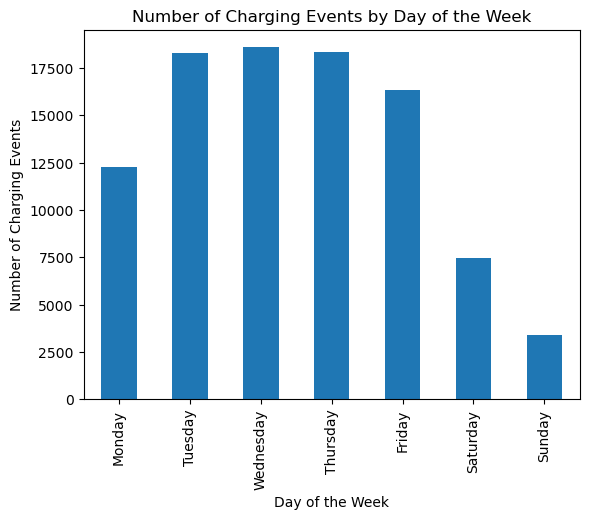

In [36]:
def get_active_weekdays(row):
    start=row['connectionTime'].date()
    end=row['disconnectTime'].date()
    weekday_range=pd.date_range(start=start,end=end,freq='D')
    return [weekday.day_name() for weekday in weekday_range]
new_df['active_weekday'] = new_df.apply(get_active_weekdays,axis=1)
all_weekdays=[weekday for weekdays in new_df['active_weekday'] for weekday in weekdays]
weekly_counts = pd.Series(all_weekdays).value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
weekly_counts.plot(kind='bar')
plt.title('Number of Charging Events by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Charging Events')
plt.show()

The charging volume from Monday to Friday is significantly higher than on weekends, possibly due to weekday commuting.

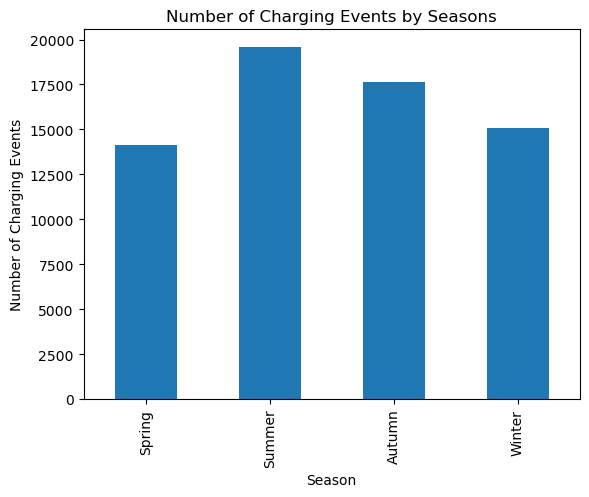

In [37]:
def map_season(month):
    if month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Autumn'
    else:
        return 'Winter'
def get_seasons(row):
    date_range=pd.date_range(start=row['connectionTime'],end=row['disconnectTime'])
    seasons=[map_season(date.month)for date in date_range]
    return list(set(seasons))
new_df['seasons']=new_df.apply(get_seasons,axis=1)
all_seasons=[season for seasons in new_df['seasons'] for season in seasons]
seasonal_counts=pd.Series(all_seasons).value_counts().reindex(['Spring', 'Summer', 'Autumn', 'Winter'])
seasonal_counts.plot(kind='bar')
plt.title('Number of Charging Events by Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Charging Events')
plt.show()

The charging volume is higher in summer and autumn, possibly because people travel more during warmer weather.

### 2.b Key Performance Indicators (KPIs): Define three time-dependent KPIs that you would include in a dashboard for the hub operator. These KPIs must provide an immediate overview of the current hub operation and how it is doing in terms of utilization or other business-related aspects. Briefly explain the rationale behind selecting each KPI, explain why you have chosen it and, where needed, provide references. Calculate hourly values for the selected KPIs and visualize them over time. Which trends do you observe? How do you explain them?

'spaceID' is the unique identifier of the parking space, so there are 107 parking spaces.

#### Hourly Charging Session Starts(Predicting Peak Hours of User Activity at Charging Stations)

C:\Users\86157\AppData\Local\Temp\ipykernel_27332\103101549.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_df['hour'] = pd.to_datetime(new_df['connectionTime']).dt.floor('H')


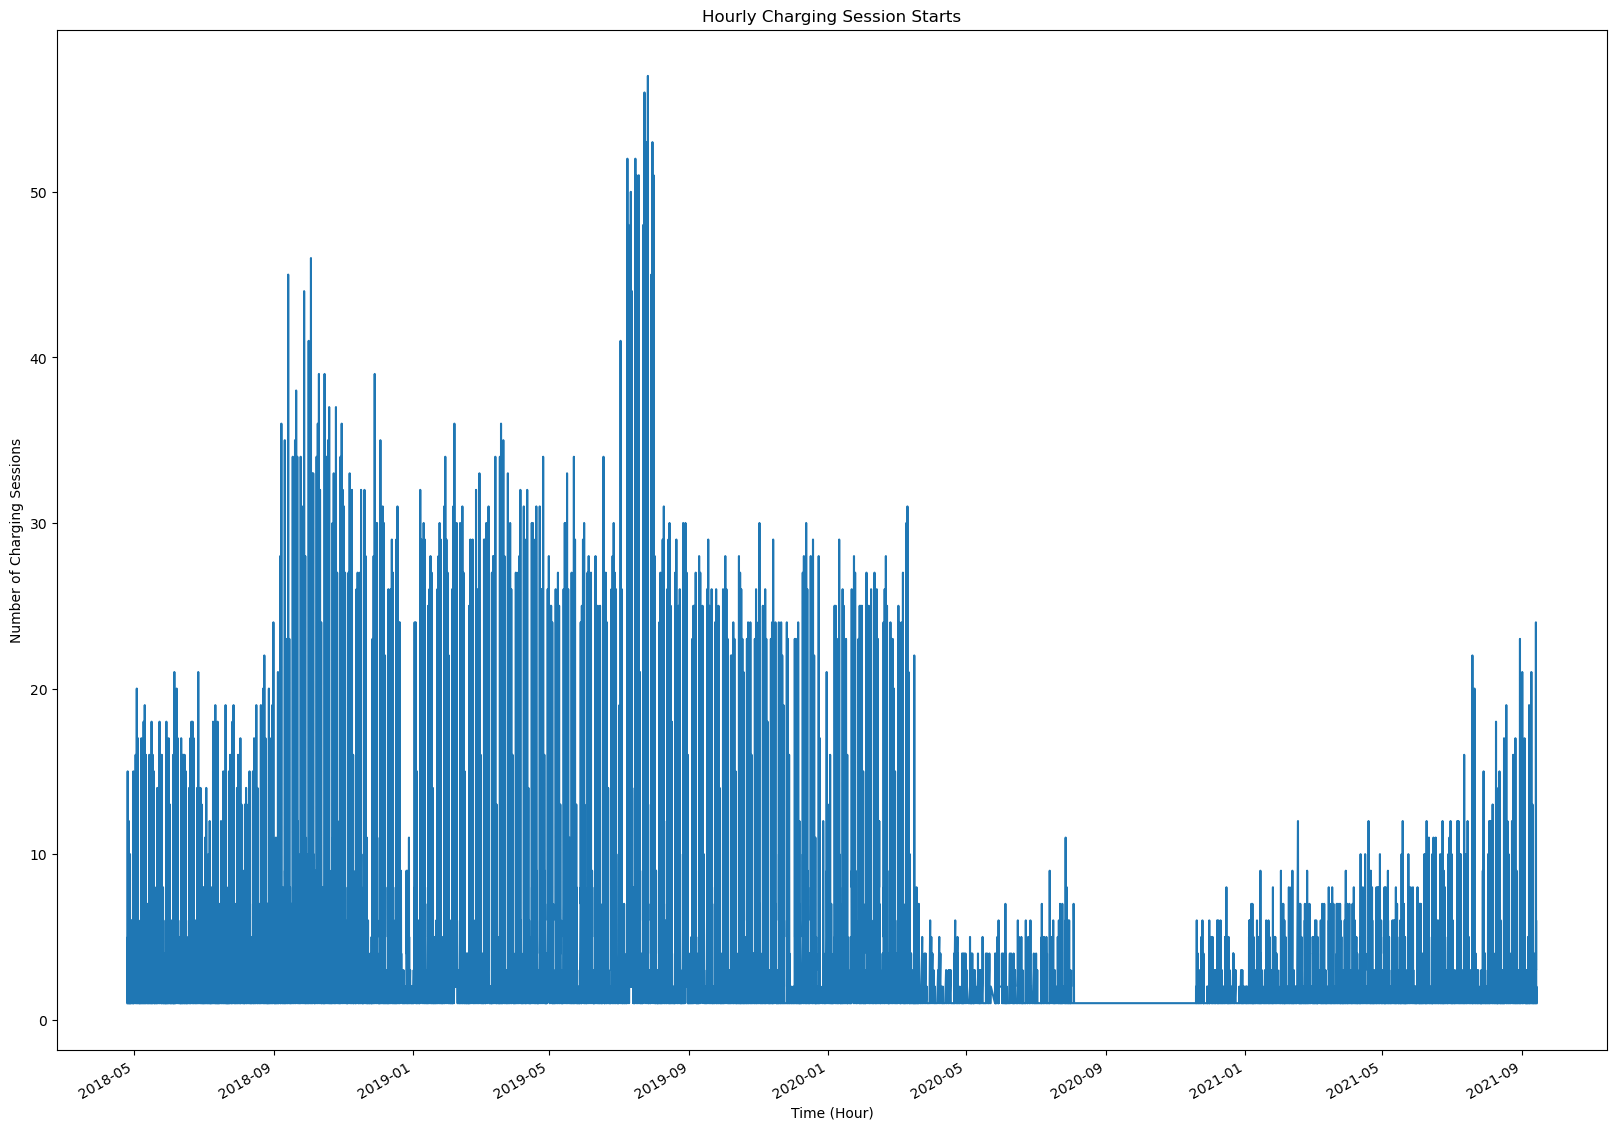

In [38]:
new_df['hour'] = pd.to_datetime(new_df['connectionTime']).dt.floor('H')
hourly_sessions_started = new_df.groupby('hour').size()
hourly_sessions_started.plot(kind='line',figsize=(20, 15),title='Hourly Charging Session Starts')
plt.xlabel('Time (Hour)')
plt.ylabel('Number of Charging Sessions')
plt.show()

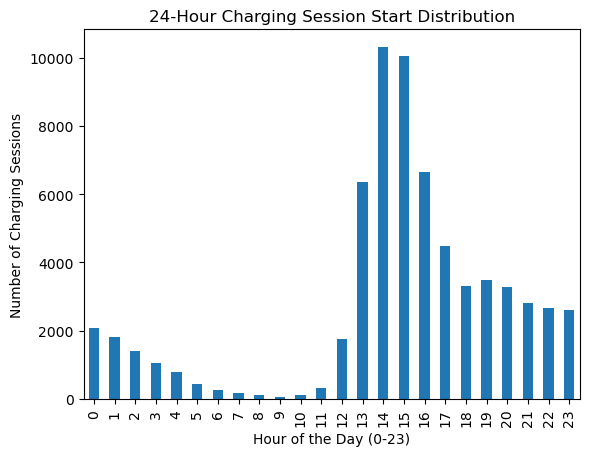

In [39]:
new_df['hour'] = pd.to_datetime(new_df['connectionTime'])
new_df['hour_of_day'] = new_df['hour'].dt.hour
hourly_distribution = new_df.groupby('hour_of_day').size()
hourly_distribution.plot(kind='bar', title='24-Hour Charging Session Start Distribution')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Charging Sessions')
plt.show()

The period from 1 pm to 4 pm is the time when the most people go to charge their vehicles, likely because it is a common preparation stage for many users' afternoon travels. To ensure sufficient battery levels, they choose to charge during this time.

#### Hourly Charging Session Disconnections (Identifying Key Hours of User Activity Completion at Charging Stations)

C:\Users\86157\AppData\Local\Temp\ipykernel_27332\3363315181.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_df['hour_disconnected'] = pd.to_datetime(new_df['disconnectTime']).dt.floor('H')


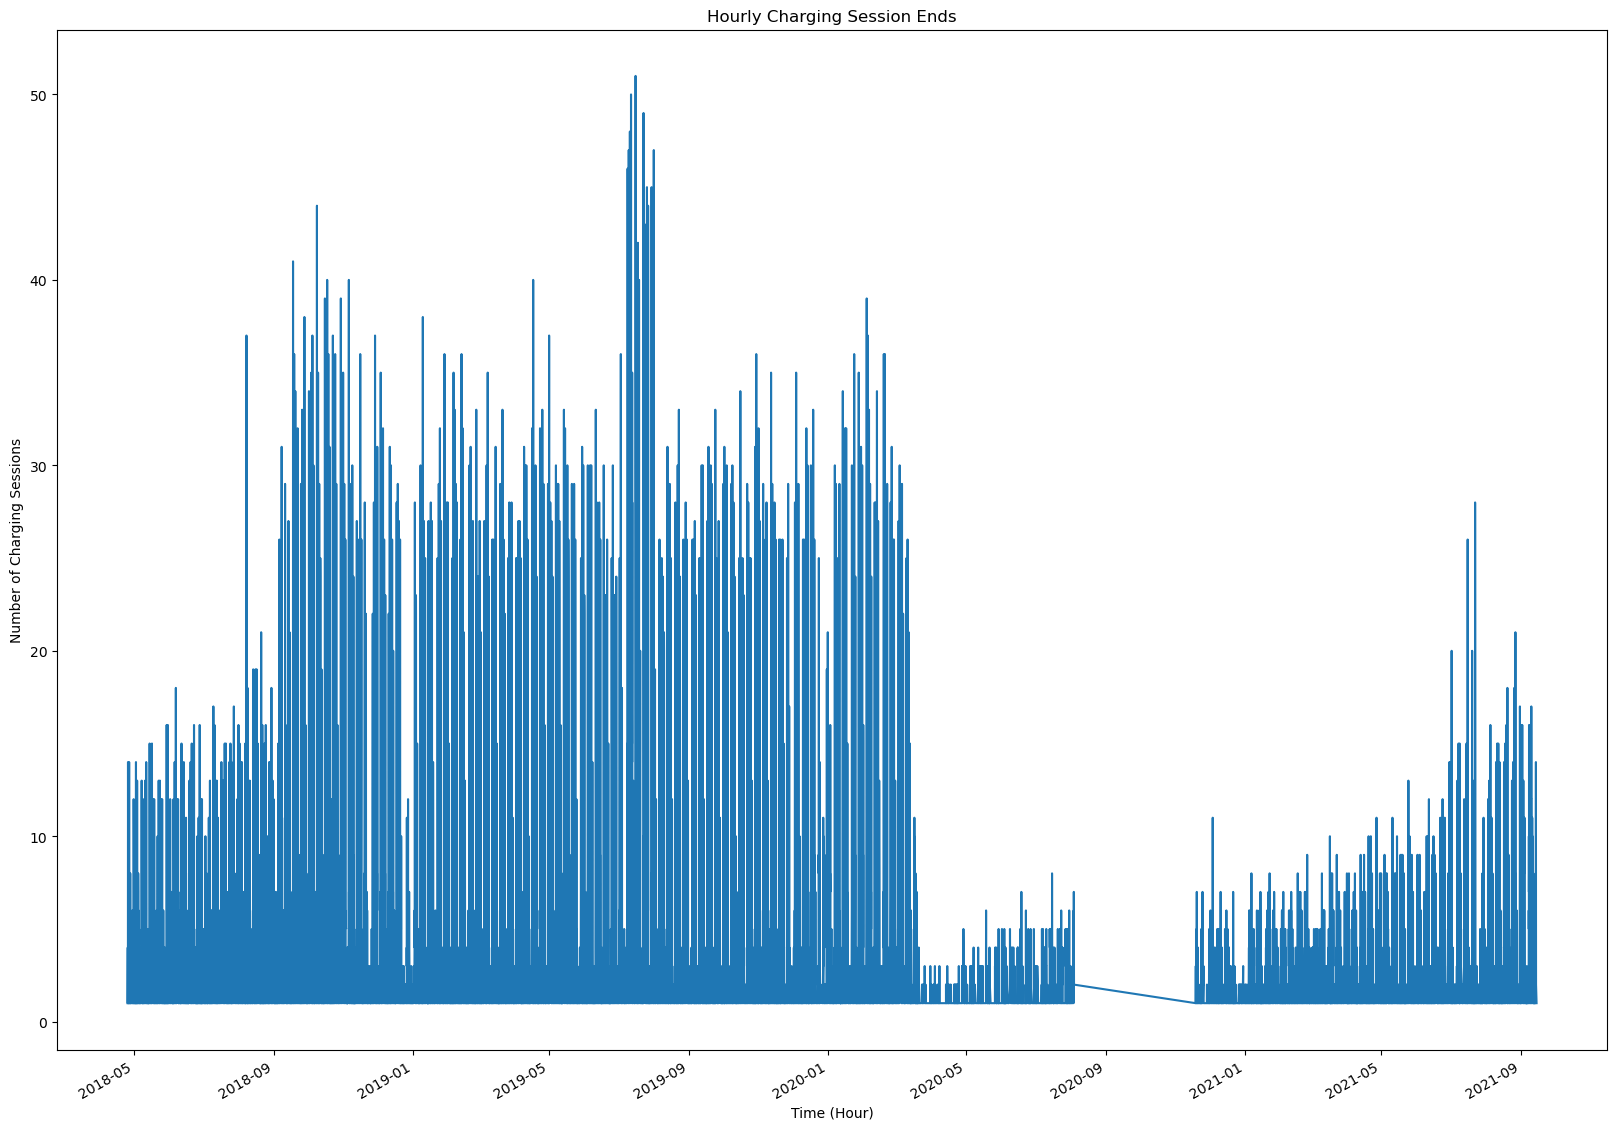

In [40]:
new_df['hour_disconnected'] = pd.to_datetime(new_df['disconnectTime']).dt.floor('H')
hourly_sessions_disconnected = new_df.groupby('hour_disconnected').size()
hourly_sessions_disconnected.plot(kind='line',figsize=(20, 15),title='Hourly Charging Session Ends')
plt.xlabel('Time (Hour)')
plt.ylabel('Number of Charging Sessions')
plt.show()

Since September 2018, both the number of charging session starts and ends saw a significant increase. However, starting in 2020, the number of charging session starts sharply declined, and then began to slowly increase again from 2021.  
The increase in charging session numbers in 2018 could be attributed to the rapid development of electric vehicles. The decline in early 2020 was likely due to the pandemic, while the recovery after 2021 indicates the recovery from the pandemic and the growth in electric vehicle usage.

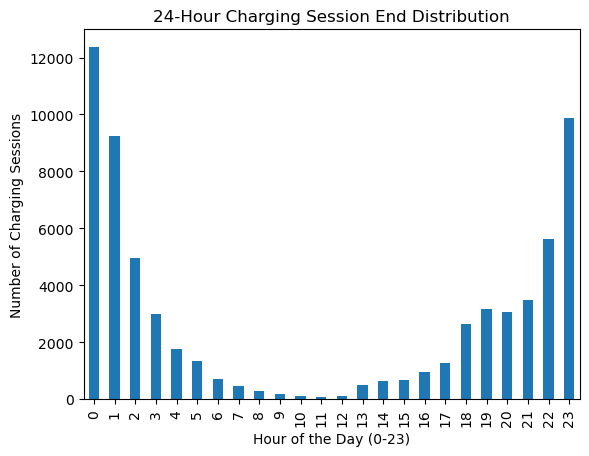

In [41]:
new_df['hour_disconnected'] = pd.to_datetime(new_df['disconnectTime'])
new_df['hour_of_disconnected'] = new_df['hour_disconnected'].dt.hour
hourly_distribution = new_df.groupby('hour_of_disconnected').size()
hourly_distribution.plot(kind='bar', title='24-Hour Charging Session End Distribution')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Charging Sessions')
plt.show()

A large number of charging sessions end in the early hours, especially between 11 pm and 1 Aam.

#### Hourly Utilization Rate(Allocating and Optimizing Resources)

In [42]:
from collections import defaultdict
new_df['connectionTime'] = pd.to_datetime(new_df['connectionTime'])
new_df['disconnectTime'] = pd.to_datetime(new_df['disconnectTime'])
num_charging_stations = new_df['stationID'].nunique()
def calculate_hourly_utilization(row):
    hourly_utilization = defaultdict(float)
    hourly_ranges = pd.date_range(start=row['connectionTime'], end=row['disconnectTime'], freq='H')
    if row['disconnectTime'] in hourly_ranges:
        hourly_ranges = hourly_ranges[:-1]
    for hour in hourly_ranges:
        hour_start = max(row['connectionTime'], hour)
        hour_end = min(row['disconnectTime'], hour + pd.Timedelta(hours=1))
        duration_in_minutes = (hour_end - hour_start).total_seconds() / 60
        hourly_utilization[hour] += duration_in_minutes
    return hourly_utilization

C:\Users\86157\AppData\Local\Temp\ipykernel_27332\1457631082.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_ranges = pd.date_range(start=row['connectionTime'], end=row['disconnectTime'], freq='H')


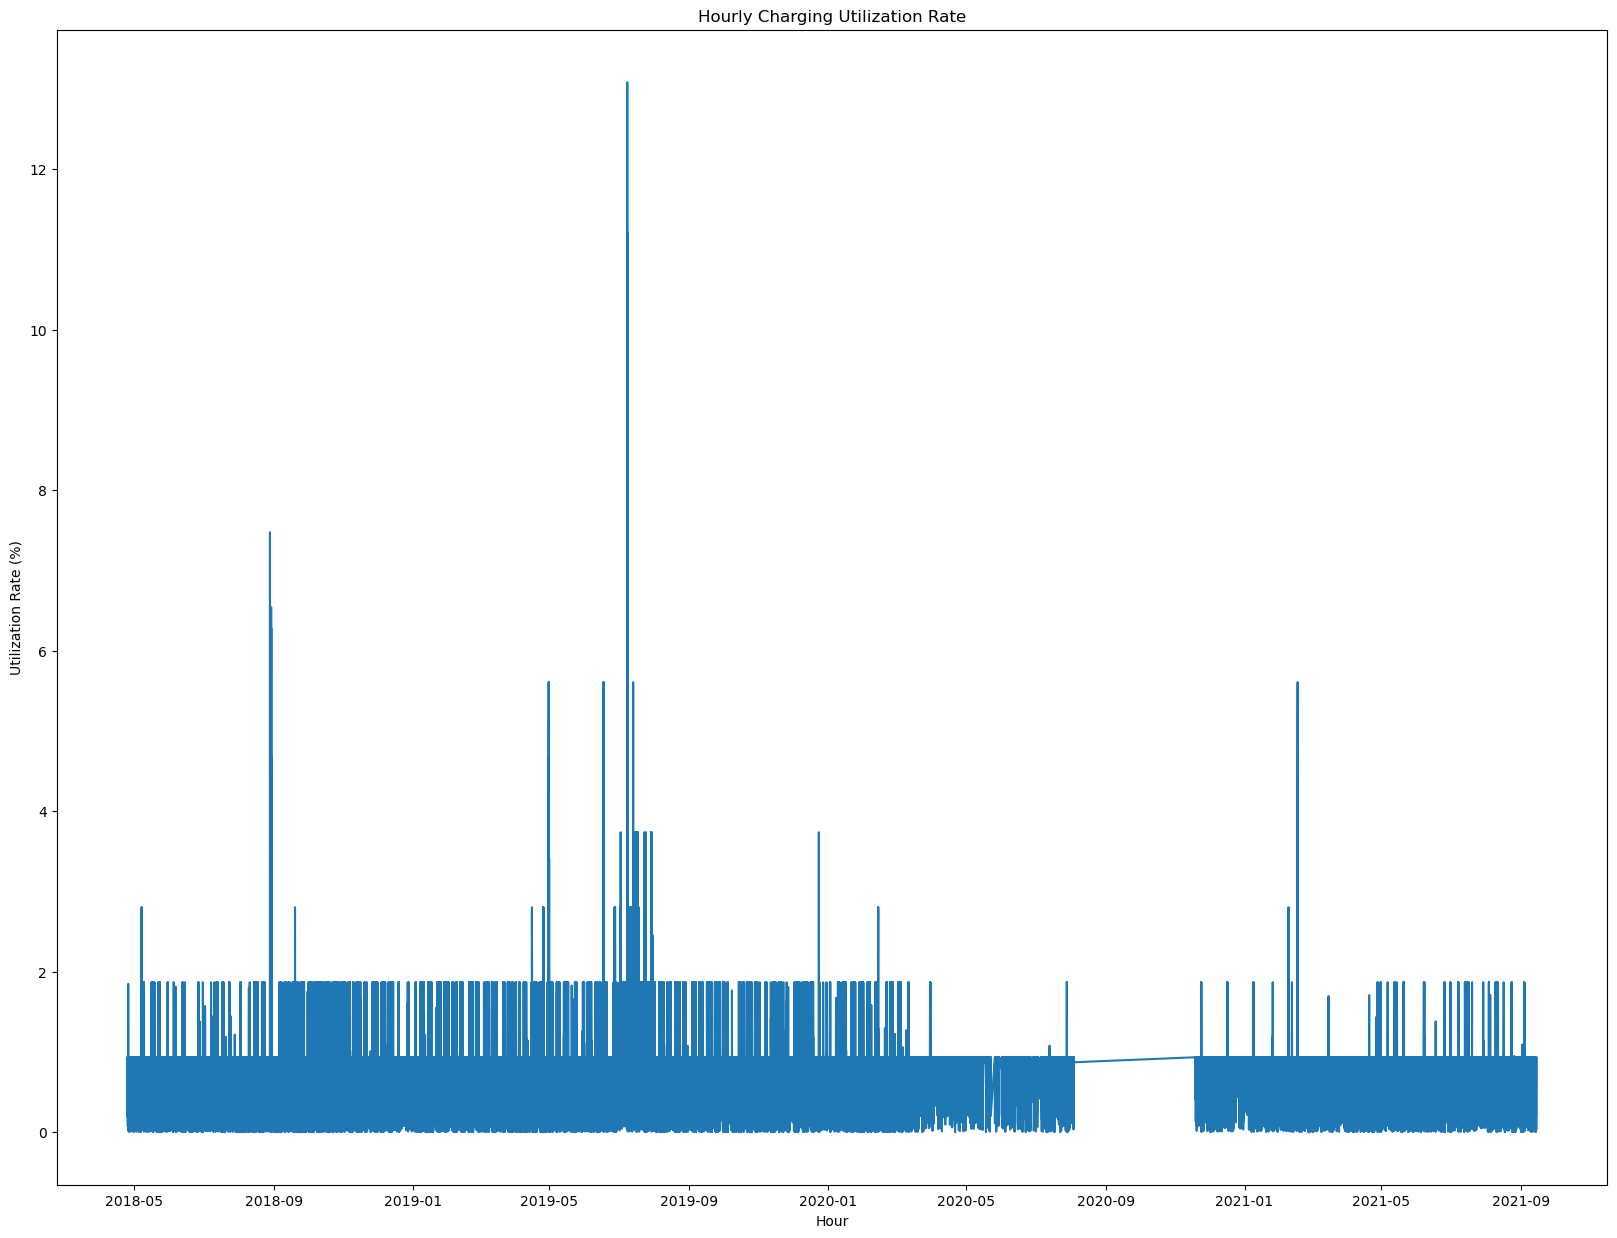

In [43]:
total_hourly_usage = defaultdict(float)
for _, row in new_df.iterrows():
    hourly_usage = calculate_hourly_utilization(row)
    for hour, duration in hourly_usage.items():
        total_hourly_usage[hour] += duration
total_minutes_per_hour = num_charging_stations * 60
utilization_rate = {hour: (duration / total_minutes_per_hour * 100) for hour, duration in total_hourly_usage.items()}
utilization_df = pd.DataFrame(list(utilization_rate.items()), columns=['Hour', 'Utilization Rate (%)'])
utilization_df = utilization_df.sort_values('Hour')
plt.figure(figsize=(20, 15))
plt.plot(utilization_df['Hour'], 
utilization_df['Utilization Rate (%)'])
plt.title('Hourly Charging Utilization Rate')
plt.xlabel('Hour')
plt.ylabel('Utilization Rate (%)')
plt.show()

The utilization rate remains relatively low. This could be due to the relatively low adoption rate of electric vehicles.

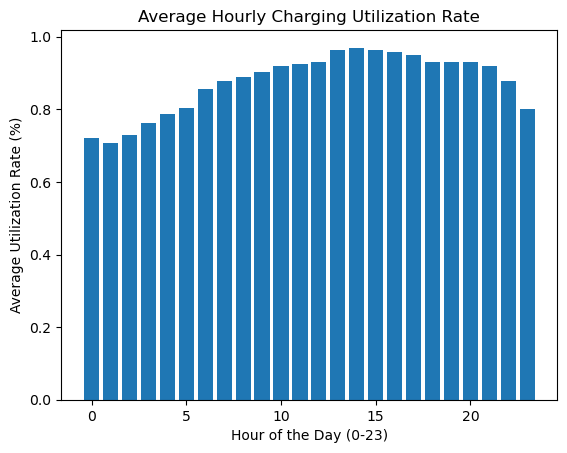

In [44]:
utilization_df['Hour_of_Day'] = utilization_df['Hour'].dt.hour
hourly_avg_utilization = utilization_df.groupby('Hour_of_Day')['Utilization Rate (%)'].mean()
plt.bar(hourly_avg_utilization.index, hourly_avg_utilization.values)
plt.title('Average Hourly Charging Utilization Rate')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Average Utilization Rate (%)')
plt.show()

The overall utilization rate throughout the day is relatively low, with no significant fluctuations.

#### Hourly Energy Delivered(Evaluating Charging Station Load)

In [45]:
def calculate_hourly_energy(row):
    energy_per_minute = row['kWhDelivered'] / row['Connection_Time_minutes']
    hourly_energy = defaultdict(float)
    hourly_ranges = pd.date_range(start=row['connectionTime'], end=row['disconnectTime'], freq='H')
    if row['disconnectTime'] in hourly_ranges:
        hourly_ranges = hourly_ranges[:-1]   
    for hour in hourly_ranges:
        hour_start = max(row['connectionTime'], hour)
        hour_end = min(row['disconnectTime'], hour + pd.Timedelta(hours=1))
        duration_in_minutes = (hour_end - hour_start).total_seconds() / 60
        hourly_energy[hour] += energy_per_minute * duration_in_minutes
    return hourly_energy

C:\Users\86157\AppData\Local\Temp\ipykernel_27332\3180946039.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_ranges = pd.date_range(start=row['connectionTime'], end=row['disconnectTime'], freq='H')


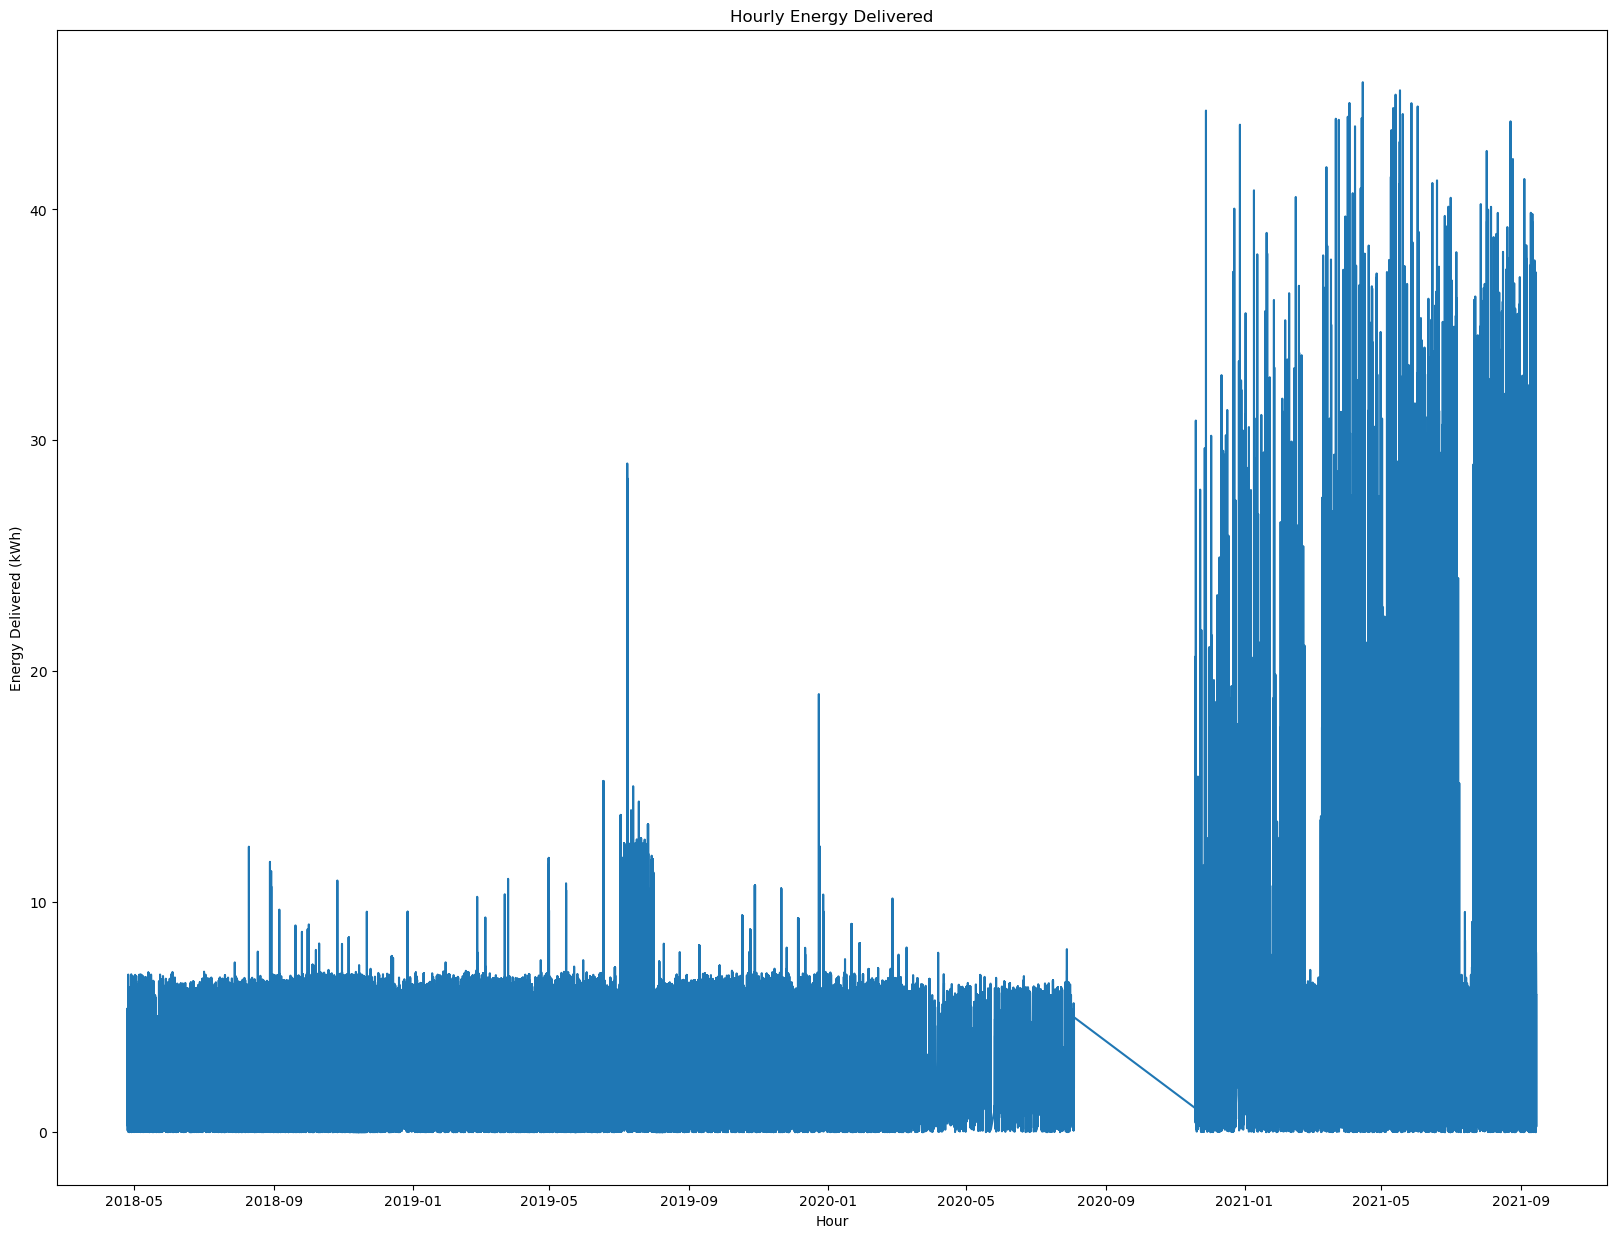

In [46]:
total_hourly_energy = defaultdict(float)
for _, row in new_df.iterrows():
    hourly_energy = calculate_hourly_energy(row)
    for hour, energy in hourly_energy.items():
        total_hourly_energy[hour] += energy
hourly_energy_df = pd.DataFrame(list(total_hourly_energy.items()), columns=['Hour', 'Energy Delivered (kWh)'])
hourly_energy_df = hourly_energy_df.sort_values('Hour')
plt.figure(figsize=(20, 15))
plt.plot(hourly_energy_df['Hour'], hourly_energy_df['Energy Delivered (kWh)'])
plt.title('Hourly Energy Delivered')
plt.xlabel('Hour')
plt.ylabel('Energy Delivered (kWh)')
plt.show()

Previously, we observed that Hourly Charging Session Starts, Hourly Charging Session Ends and Hourly Charging Utilization Rate decreased after 2021. However, the significant increase in Hourly Energy Delivered during the same period may be due to the next generation of electric vehicles or charging equipment likely supporting higher power capabilities.

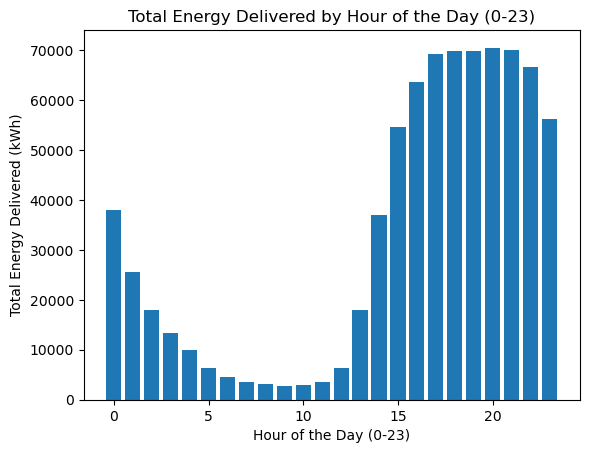

In [47]:
hourly_energy_df['Hour_of_Day'] = hourly_energy_df['Hour'].dt.hour
hourly_energy_grouped = hourly_energy_df.groupby('Hour_of_Day')['Energy Delivered (kWh)'].sum()
plt.bar(hourly_energy_grouped.index, hourly_energy_grouped.values)
plt.title('Total Energy Delivered by Hour of the Day (0-23)')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Total Energy Delivered (kWh)')
plt.show()

### 2.c Site Characteristics: The hub operator provided you with the data set, but has seemed to forget which site was supplying which data... Can you find out which of the two sites is the public one? Try to combine data understanding from previous descriptive analytics with domain knowledge (business understanding) of how private vs. public charging hubs might differ in operation. Explain your line of thought!

The private site is likely to consist mostly of registered users, with usage concentrated on weekdays.

In [48]:
registered_users_df = new_df[new_df['userID'] != -1]
registered_user_count = registered_users_df.groupby('siteID')['userID'].nunique()
print(registered_user_count)

siteID
1    522
2    571
Name: userID, dtype: int64


In [49]:
registered_session_count = registered_users_df.groupby('siteID')['sessionID'].count()
print(registered_session_count)

siteID
1    32814
2    16367
Name: sessionID, dtype: int64


In [50]:
session_count = new_df.groupby('siteID')['sessionID'].nunique()
print(session_count)

siteID
1    33628
2    31382
Name: sessionID, dtype: int64


In [51]:
print(new_df.head())

   Unnamed: 0.1  Unnamed: 0                        id      connectionTime  \
0             0           0  5e23b149f9af8b5fe4b973cf 2020-01-02 13:08:54   
1             1           1  5e23b149f9af8b5fe4b973d0 2020-01-02 13:36:50   
2             2           2  5e23b149f9af8b5fe4b973d1 2020-01-02 13:56:35   
3             3           3  5e23b149f9af8b5fe4b973d2 2020-01-02 13:59:58   
4             4           4  5e23b149f9af8b5fe4b973d3 2020-01-02 14:00:01   

       disconnectTime               doneChargingTime  kWhDelivered  \
0 2020-01-02 19:11:15  2020-01-02 17:31:35.000000000        25.016   
1 2020-01-02 22:38:21  2020-01-02 20:18:05.000000000        33.097   
2 2020-01-03 00:39:22  2020-01-02 16:35:06.000000000         6.521   
3 2020-01-02 16:38:39  2020-01-02 15:18:45.000000000         2.355   
4 2020-01-02 22:08:40  2020-01-02 18:17:30.000000000        13.375   

                                sessionID  siteID  spaceID  ... pressure  \
0  1_1_179_810_2020-01-02 13:08:53.87003

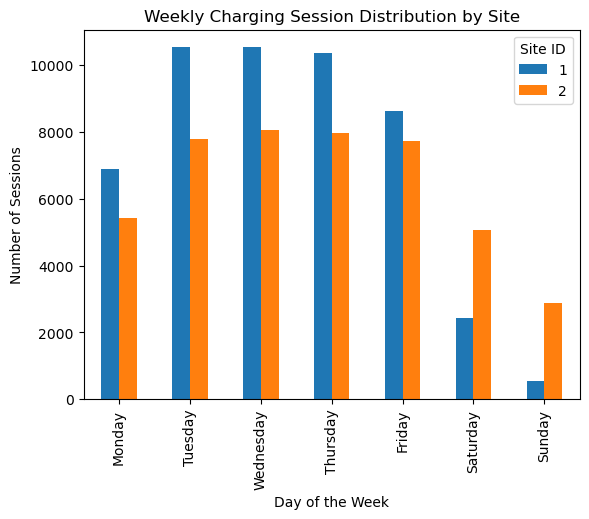

In [52]:
expanded_weekdays = new_df.explode('active_weekday')
weekday_distribution = expanded_weekdays.groupby(['siteID', 'active_weekday']).size().unstack()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_distribution = weekday_distribution.reindex(columns=weekday_order)
weekday_distribution.T.plot(kind='bar')
plt.title('Weekly Charging Session Distribution by Site')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Sessions')
plt.legend(title='Site ID')
plt.show()

Most of the sessions at Site 1 are conducted by registered users, while the proportion of sessions by registered users is smaller at Site 2.   
Charging usage at Site 1 peaks from Monday to Friday, especially on weekdays, with significantly reduced usage on weekends.  
Therefore, Site ID 1 is identified as a private site, while Site ID 2 is a public site.